# PACT-GRPO: kết quả thực nghiệm

Notebook đọc kết quả đã lưu trong `outputs/verified_pilot` và hiển thị bốn biểu đồ. Chọn kernel của môi trường `tf_gpu`, rồi chạy các cell theo thứ tự. Có thể đổi `SCALE` ở cell đầu khi có kết quả khác.


In [1]:
"""Read the saved benchmark results without rerunning model training."""

from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


ROOT = Path(r"E:\DATN\pact_grpo_math")
SCALE = "verified_pilot"
SHOW_PLOTS = True
METHODS = ["base", "grpo", "dr_grpo", "pcgrad_grpo", "pact_grpo"]
LABELS = {
    "base": "Base",
    "grpo": "GRPO",
    "dr_grpo": "Dr. GRPO",
    "pcgrad_grpo": "PCGrad-GRPO",
    "pact_grpo": "PACT-GRPO",
}
COLORS = {
    "base": "#8A8F98",
    "grpo": "#0072B2",
    "dr_grpo": "#56B4E9",
    "pcgrad_grpo": "#009E73",
    "pact_grpo": "#D55E00",
}



In [2]:
def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else {}


def load_jsonl(path: Path) -> list[dict]:
    if not path.exists():
        return []
    with path.open(encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]


def empty_panel(axis, message: str) -> None:
    axis.text(0.5, 0.5, message, ha="center", va="center", transform=axis.transAxes, color="#777777")


def moving_average(values: list[float], window: int = 10) -> np.ndarray:
    numbers = np.asarray(values, dtype=float)
    if numbers.size < window:
        return numbers
    return np.convolve(numbers, np.ones(window) / window, mode="valid")


def wilson_interval(correct: int, samples: int, z: float = 1.96) -> tuple[float, float]:
    """Approximate 95% interval for a binomial accuracy estimate."""
    if samples <= 0:
        return 0.0, 0.0
    p = correct / samples
    denominator = 1 + z * z / samples
    center = (p + z * z / (2 * samples)) / denominator
    half_width = z * np.sqrt(p * (1 - p) / samples + z * z / (4 * samples * samples)) / denominator
    return 100 * (center - half_width), 100 * (center + half_width)


def make_dashboard(output_dir: Path) -> tuple[Path, Path]:
    evaluations = {
        method: load_json(output_dir / method / "evaluation" / "metrics.json")
        for method in METHODS
    }
    histories = {
        method: load_jsonl(output_dir / method / "train_metrics.jsonl")
        for method in METHODS if method != "base"
    }
    if not any(evaluations.values()) and not any(histories.values()):
        raise FileNotFoundError(f"No evaluation or training results found in {output_dir}")

    plt.rcParams.update({
        "font.family": "DejaVu Sans", "font.size": 10,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.alpha": 0.15,
        "savefig.dpi": 300,
    })
    figure, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
    accuracy_ax, reward_ax, rsvr_ax, norm_ax = axes.flat

    present = [method for method in METHODS if evaluations[method]]
    if present:
        x = np.arange(len(present))
        width = 0.36
        for offset, dataset, label, alpha in [
            (-width / 2, "gsm8k", "GSM8K", 1.0),
            (width / 2, "math500", "MATH-500 strict", 0.55),
        ]:
            values = [100 * evaluations[m].get(dataset, {}).get("accuracy", np.nan) for m in present]
            bars = accuracy_ax.bar(
                x + offset, values, width, label=label,
                color=[COLORS[m] for m in present], alpha=alpha,
            )
            for method, bar, value in zip(present, bars, values):
                if np.isfinite(value):
                    record = evaluations[method].get(dataset, {})
                    n = int(record.get("samples", 0))
                    low, high = wilson_interval(int(record.get("correct", 0)), n)
                    accuracy_ax.errorbar(
                        bar.get_x() + bar.get_width()/2, value,
                        yerr=[[max(0, value - low)], [max(0, high - value)]],
                        fmt="none", ecolor="#333333", capsize=3, linewidth=1,
                    )
                    accuracy_ax.text(bar.get_x() + bar.get_width()/2, high + 1,
                                     f"{value:.1f}%\nn={n}", ha="center", va="bottom", fontsize=7)
        accuracy_ax.set_xticks(x, [LABELS[m] for m in present], rotation=20, ha="right")
        accuracy_ax.set_ylim(0, max(10, accuracy_ax.get_ylim()[1] * 1.20))
        accuracy_ax.legend(frameon=False, fontsize=8)
    else:
        empty_panel(accuracy_ax, "Run evaluate.py to populate accuracy")
    accuracy_ax.set_title("Held-out answer accuracy (95% Wilson intervals)")
    accuracy_ax.set_ylabel("Exact match (%)")

    for method, rows in histories.items():
        if not rows:
            continue
        # Reward repeats for policy epochs; use the first row of each sampled group.
        first_epoch = [row for row in rows if row.get("epoch", 1) == 1]
        values = [float(row["reward_mean"]) for row in first_epoch]
        smooth = moving_average(values)
        start = len(values) - len(smooth) + 1
        reward_ax.plot(range(start, len(values) + 1), smooth,
                       label=LABELS[method], color=COLORS[method], linewidth=1.8)
    if not reward_ax.lines:
        empty_panel(reward_ax, "Run train.py to populate reward curves")
    else:
        reward_ax.legend(frameon=False, fontsize=8)
    reward_ax.set_title("Training reward (moving average)")
    reward_ax.set_xlabel("Sampled question group")
    reward_ax.set_ylabel("Mean reward")

    for method, rows in histories.items():
        if not rows:
            continue
        steps = np.arange(1, len(rows) + 1)
        if method == "pact_grpo":
            before = [100 * float(row["rsvr_before"]) for row in rows]
            rsvr_ax.plot(steps, before, label="PACT before projection",
                         color=COLORS[method], linestyle="--", linewidth=1.2,
                         marker="o", markersize=3, alpha=0.65)
        after = [100 * float(row["rsvr_after"]) for row in rows]
        rsvr_ax.plot(steps, after, label=("PACT after projection" if method == "pact_grpo" else LABELS[method]),
                     color=COLORS[method], linewidth=1.8, marker="o", markersize=3)
    if not rsvr_ax.lines:
        empty_panel(rsvr_ax, "Run train.py to populate RSVR")
    else:
        rsvr_ax.legend(frameon=False, fontsize=8)
    rsvr_ax.set_title("Rollout sign violation rate")
    rsvr_ax.set_xlabel("Optimizer update")
    rsvr_ax.set_ylabel("RSVR (%)")
    rsvr_ax.set_ylim(0, 30)

    available = [m for m in METHODS[1:] if histories[m]]
    if available:
        counts = [sum(bool(row["projection_applied"]) for row in histories[m]) for m in available]
        rates = [100 * count / len(histories[m]) for count, m in zip(counts, available)]
        bars = norm_ax.bar([LABELS[m] for m in available], rates,
                           color=[COLORS[m] for m in available], width=0.6)
        norm_ax.tick_params(axis="x", labelrotation=20)
        norm_ax.set_ylim(0, max(15, max(rates) * 1.25))
        for bar, value, count, method in zip(bars, rates, counts, available):
            norm_ax.text(bar.get_x() + bar.get_width()/2, value + 0.5,
                         f"{count}/{len(histories[method])} ({value:.1f}%)", ha="center", fontsize=8)
    else:
        empty_panel(norm_ax, "Run train.py to populate projection counts")
    norm_ax.set_title("Updates requiring projection")
    norm_ax.set_ylabel("Optimizer updates (%)")

    figure.suptitle(f"PACT-GRPO math pilot — {SCALE}", fontsize=14, fontweight="bold")
    figure_dir = output_dir / "figures"
    figure_dir.mkdir(parents=True, exist_ok=True)
    png = figure_dir / "benchmark_dashboard.png"
    pdf = figure_dir / "benchmark_dashboard.pdf"
    figure.savefig(png)
    figure.savefig(pdf)
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(figure)
    return png, pdf


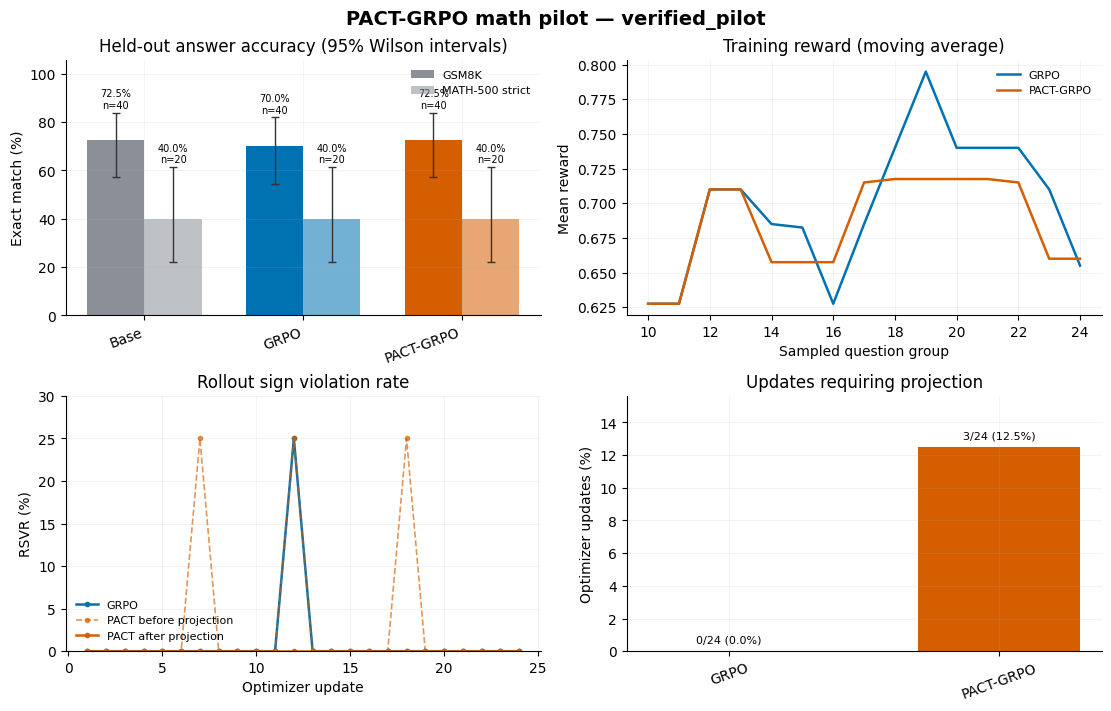

Saved: E:\DATN\pact_grpo_math\outputs\verified_pilot\figures\benchmark_dashboard.png E:\DATN\pact_grpo_math\outputs\verified_pilot\figures\benchmark_dashboard.pdf


In [3]:
png_path, pdf_path = make_dashboard(ROOT / 'outputs' / SCALE)
print('Saved:', png_path, pdf_path)


In [4]:
for method in METHODS:
    folder = ROOT / 'outputs' / SCALE / method
    metrics = load_json(folder / 'evaluation' / 'metrics.json')
    summary = load_json(folder / 'summary.json')
    if not metrics and not summary:
        continue
    gsm = metrics.get('gsm8k', {})
    math = metrics.get('math500', {})
    print(f"{LABELS[method]}: GSM8K {gsm.get('correct', '?')}/{gsm.get('samples', '?')}, "
          f"MATH-500 {math.get('correct', '?')}/{math.get('samples', '?')}, "
          f"RSVR before {summary.get('mean_rsvr_before', float('nan')):.3f}, "
          f"after {summary.get('mean_post_update_rsvr', float('nan')):.3f}")


Base: GSM8K 29/40, MATH-500 8/20, RSVR before nan, after nan
GRPO: GSM8K 28/40, MATH-500 8/20, RSVR before 0.010, after 0.010
PACT-GRPO: GSM8K 29/40, MATH-500 8/20, RSVR before 0.031, after 0.000
